###  Industry-Oriented Machine Learning System for Credit RiskAssessment

In [80]:
# importing necessary libraries 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')



### Financial dataset ingestion

In [81]:
# importing dataset
# Credit Risk & Loan Default Analysis Dataset by Muhammad Shahzad from kaggle

df = pd.read_csv('../../dataset/loan_risk_prediction_dataset.csv')
 


In [82]:

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


 ### Data preprocessing and normalization

In [83]:
df.isna().sum() # missign values are found in INCOME, Credit Score and Education
# we will use mean and mode to fill values

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [84]:

df['Income'] = df['Income'].fillna(df['Income'].mean())
df['CreditScore'] = df['CreditScore'].fillna(df['CreditScore'].mean())
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])


In [85]:
df.isna().sum() # data have no missing values now

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64

In [86]:
df.describe()

# min values for income and loan amount are less than 0 which is not ideal 

df[df['Income']<0] # three values in Income have negative values

df[df['LoanAmount'] < 0].count() # 28 values in income

Age                28
Income             28
LoanAmount         28
CreditScore        28
YearsExperience    28
Gender             28
Education          28
City               28
EmploymentType     28
LoanApproved       28
dtype: int64

In [87]:
df['Income'] = df['Income'].abs()
df['LoanAmount'] = df['LoanAmount'].abs()

df.describe() # negative values are converted into absolute values


,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.584600,49740.933822,19902.782200,575.494590,19.599000,0.230200
std,14.919094,14792.905919,7967.012963,157.404704,11.516837,0.421003
min,18.000000,129.000000,4.000000,300.000000,0.000000,0.000000
25%,31.000000,39990.250000,14455.250000,440.000000,10.000000,0.000000
50%,43.000000,49738.123022,19842.500000,575.494590,20.000000,0.000000
75%,56.000000,59447.000000,25326.750000,706.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [88]:
#describe the dataset
df.describe().loc[['min', 'max','mean']]
# numerical columns are age, income, loanAmount, creditScore, YearsExperience, loanApproved

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
min,18.0000,129.000000,4.0000,300.00000,0.000,0.0000
max,69.0000,99146.000000,48353.0000,849.00000,39.000,1.0000
mean,43.5846,49740.933822,19902.7822,575.49459,19.599,0.2302


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           5000 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      5000 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        5000 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


### Exploratory data analysis

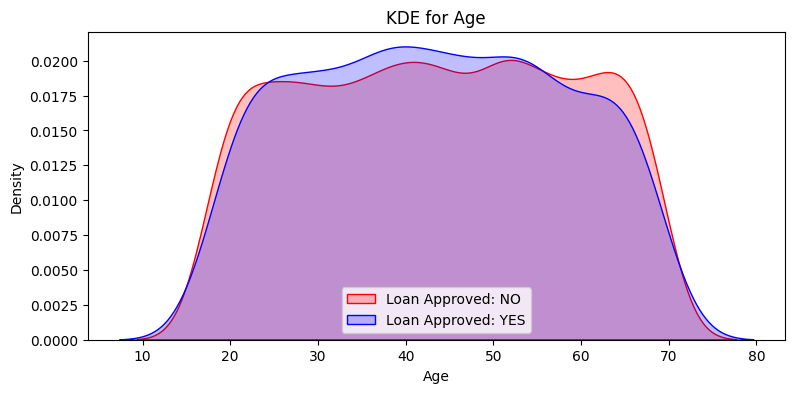

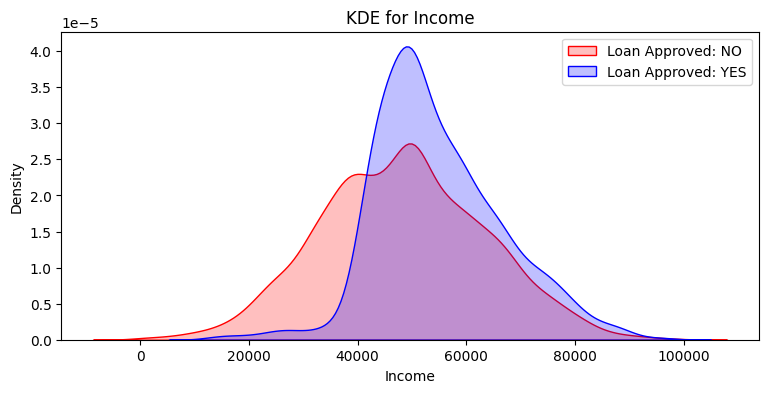

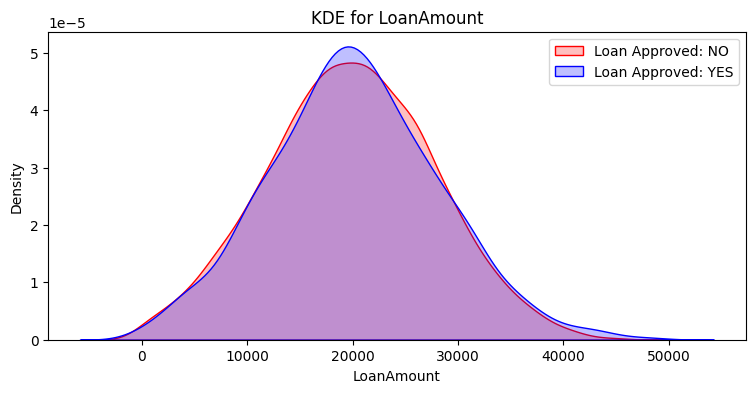

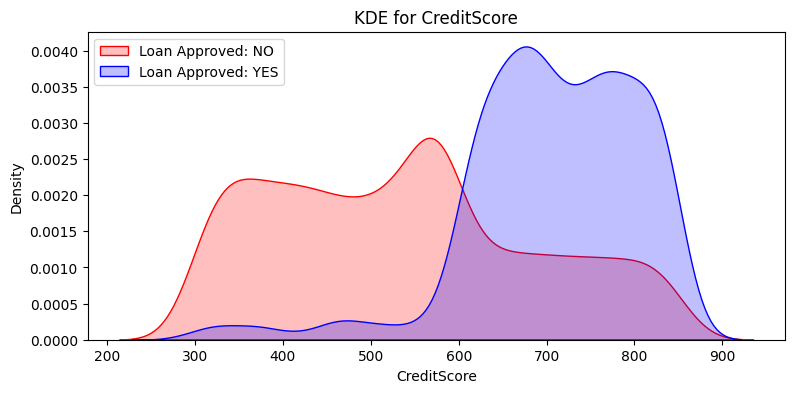

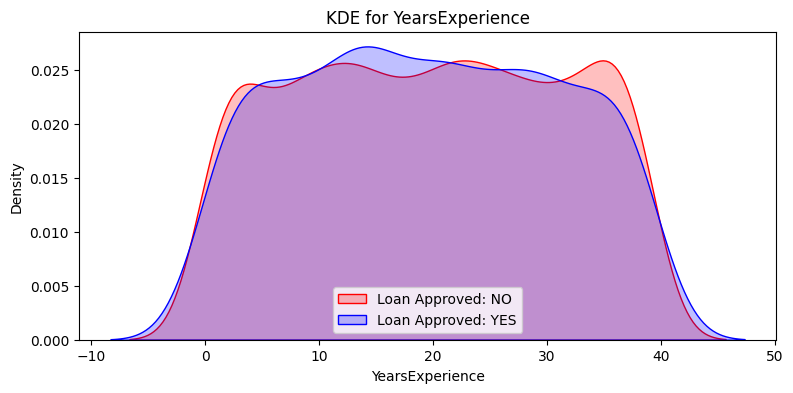

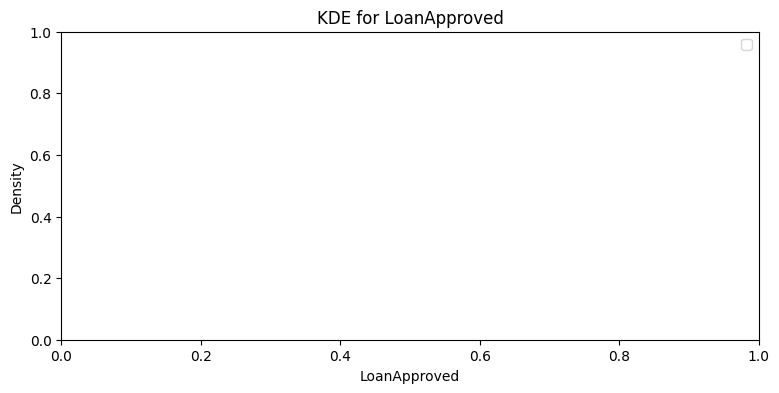

In [90]:
numerical_cols = df.select_dtypes(include=np.number).columns

# sensity plot for numerical features
def kdplot(feature):
    plt.figure(figsize=(9,4))
    plt.title(f"KDE for {feature}")

    ax0 = sns.kdeplot(df[df['LoanApproved'] == 0][feature].dropna(), color='red', label='Loan Approved: NO', fill=True)
    ax0 = sns.kdeplot(df[df['LoanApproved'] == 1][feature].dropna(), color='blue', label='Loan Approved: YES', fill=True)

    plt.legend()
    plt.show()



for i in numerical_cols:
    kdplot(i)


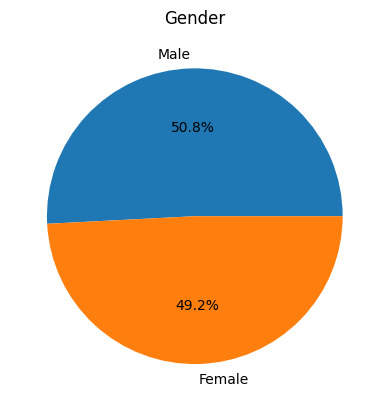

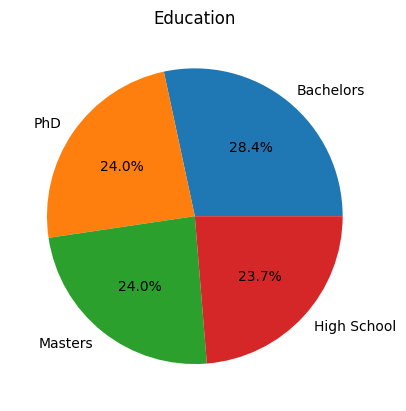

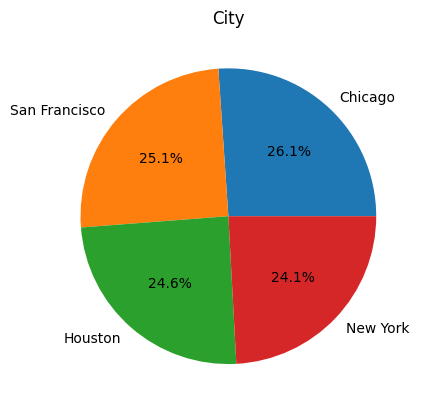

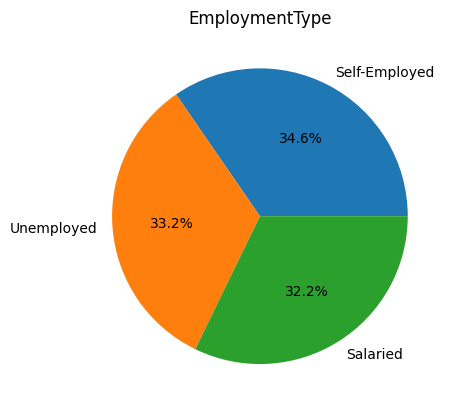

In [91]:
# pie chart for categorical features to understand each categorical field 


categorical_cols = df.select_dtypes(exclude=np.number)

for i in categorical_cols:
    counts = df[i].value_counts()
    plt.Figure(figsize=(10,10))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.title(i)
    plt.show()




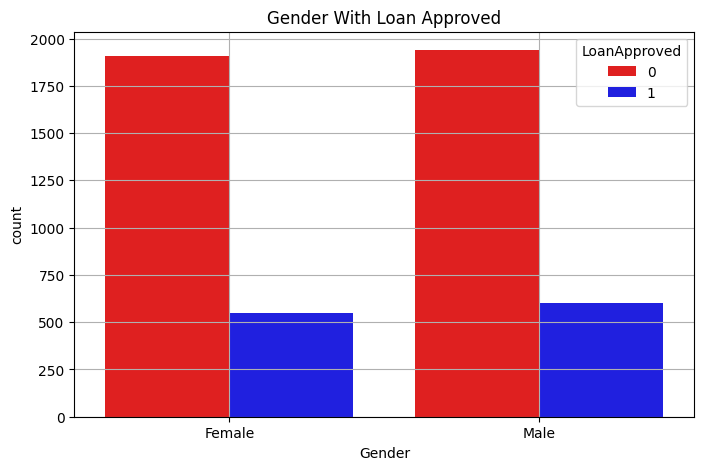

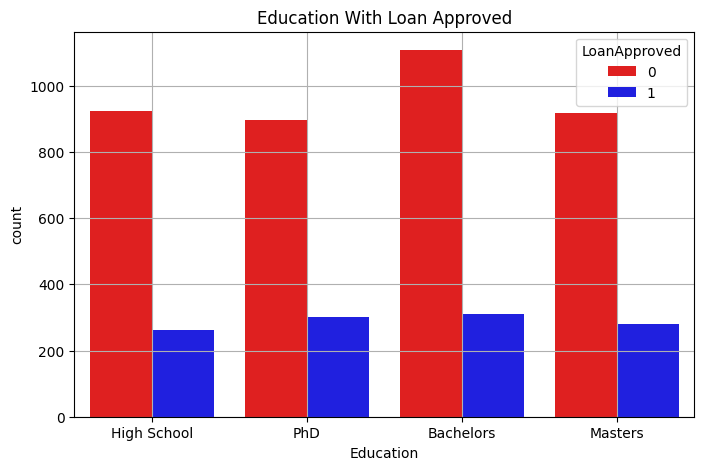

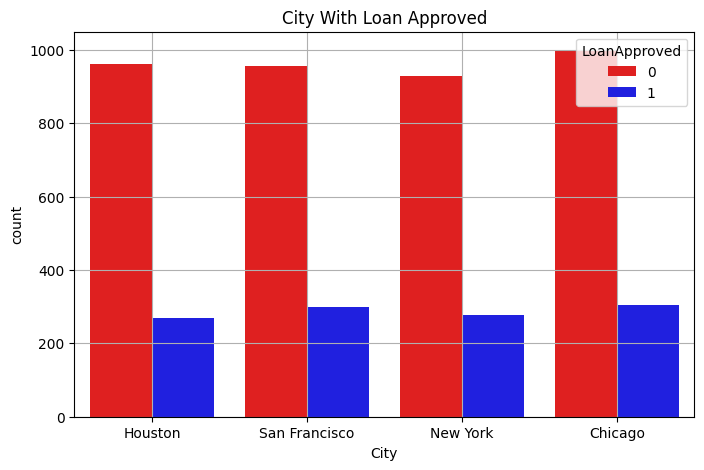

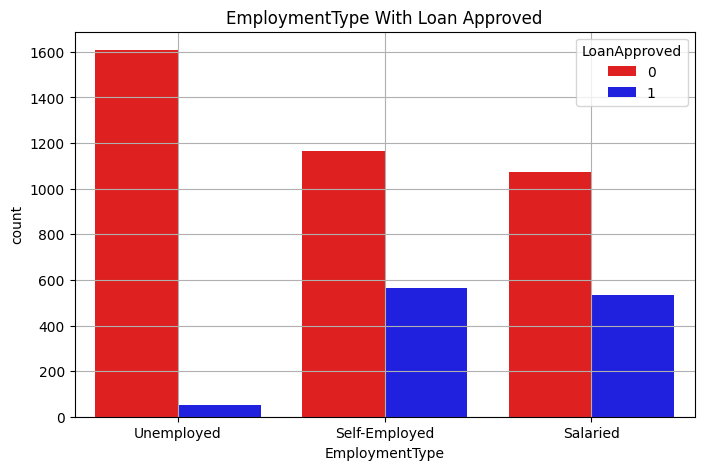

In [92]:
# countplot for categorical data to understand each categorical field in accordence with loan approved
categorical_cols = df.select_dtypes(exclude=np.number)

for i in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(x=i, hue='LoanApproved', data=df, palette=['red', 'blue'])
    plt.title(f"{i} With Loan Approved")
    plt.grid()
    plt.show()

#data is almost evanly distributed in categories 
# except Employment type in which Unemployed have least Approved loans

### Feature Engineering 

In [93]:
df.select_dtypes(include=np.number)



,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
0,56,48353.0,31258.0,675.00000,20,0
1,69,57462.0,23262.0,586.00000,6,0
2,46,44219.0,26530.0,781.00000,26,1
3,32,56307.0,11531.0,549.00000,11,0
4,60,37034.0,27871.0,500.00000,19,0
...,...,...,...,...,...,...
4995,24,36780.0,23383.0,575.49459,23,0
4996,66,99146.0,9760.0,306.00000,14,0
4997,26,58100.0,18230.0,311.00000,10,0
4998,53,58513.0,12373.0,813.00000,23,1


In [94]:
# Encoding categorical fields using one-hot coding for better model training
# using pd.get_dummies()

categorical_cols

df2 = pd.get_dummies(data=df, columns=categorical_cols.columns, dtype=float)
df2

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved,Gender_Female,Gender_Male,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,City_Chicago,City_Houston,City_New York,City_San Francisco,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.00000,20,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,69,57462.0,23262.0,586.00000,6,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,46,44219.0,26530.0,781.00000,26,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,32,56307.0,11531.0,549.00000,11,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,60,37034.0,27871.0,500.00000,19,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,575.49459,23,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4996,66,99146.0,9760.0,306.00000,14,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4997,26,58100.0,18230.0,311.00000,10,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4998,53,58513.0,12373.0,813.00000,23,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [95]:
# let aside LoanApproved column, columns like age, income, Loanamount, credit score, years of exp requires scaling
# we will use standard scaler for sklearn

from sklearn.preprocessing import StandardScaler
scale_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',]
scaler = StandardScaler()
df2[scale_cols] = scaler.fit_transform(df2[scale_cols])
df2

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved,Gender_Female,Gender_Male,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,City_Chicago,City_Houston,City_New York,City_San Francisco,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,0.832265,-0.093834,1.425422,6.322261e-01,0.034822,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.703719,0.521996,0.421683,6.674807e-02,-1.180911,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.161916,-0.373320,0.831915,1.305717e+00,0.555851,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.776573,0.443910,-1.050911,-1.683383e-01,-0.746721,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.100405,-0.859074,1.000251,-4.796689e-01,-0.052016,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.312852,-0.876246,0.436872,-7.223304e-16,0.295336,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4996,1.502614,3.340115,-1.273225,-1.712284e+00,-0.486206,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4997,-1.178782,0.565129,-0.209985,-1.680515e+00,-0.833559,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4998,0.631160,0.593051,-0.945214,1.509035e+00,0.295336,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### Model training using classification algorithms

In [96]:
#seprating features and label

x = df2.drop(columns=['LoanApproved'], axis=1)
y = df2['LoanApproved']


In [97]:
# spliting data for model training and testing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [98]:
#  importing Classification models and accuracy score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


LR = LogisticRegression(class_weight='balanced')
RFC = RandomForestClassifier(class_weight='balanced')
SVM = SVC(probability=True, class_weight='balanced')


# training and evaluation for Logistic Regression
LR.fit(x_train, y_train)
pred_LR = LR.predict(x_test)
score_LR = accuracy_score(y_test, pred_LR)
print(f"Logistic Regression Accuracy: {score_LR:.4f}")
print(classification_report(y_test, pred_LR))
print('-'*50)


# training and evaluation for Random Forest Classifier
RFC.fit(x_train, y_train)
pred_RFC = RFC.predict(x_test)
score_RFC = accuracy_score(y_test, pred_RFC)
print(f"Random Forest Classifier Accuracy: {score_RFC:.4f}")
print(classification_report(y_test, pred_RFC))
print('-'*50)


# training and evaluation for State Vector Machine
SVM.fit(x_train, y_train)
pred_SVM = LR.predict(x_test)
score_SVM = accuracy_score(y_test, pred_SVM)
print(f"S V M Accuracy: {score_SVM:.4f}")
print(classification_report(y_test, pred_SVM))
print('-'*50)





Logistic Regression Accuracy: 0.8640
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       775
           1       0.64      0.91      0.75       225

    accuracy                           0.86      1000
   macro avg       0.80      0.88      0.83      1000
weighted avg       0.89      0.86      0.87      1000

--------------------------------------------------
Random Forest Classifier Accuracy: 0.9640
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       775
           1       0.95      0.88      0.92       225

    accuracy                           0.96      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.96      0.96      0.96      1000

--------------------------------------------------
S V M Accuracy: 0.8640
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       775
           1       0.64      0.91

 ### Model evaluation using precision and recall
 Logistic Regression Accuracy: 0.8810<br>
 Random Forest Accuracy: 0.9630 <br>
 SVM Accuracy: 0.9270 <br>

Logistic Regression Accuracy: 0.8810<br>
              precision    &nbsp;&nbsp;&nbsp;&nbsp;recall  &nbsp;&nbsp;&nbsp;&nbsp;f1-score   &nbsp;&nbsp;&nbsp;&nbsp;support

           0       0.91      0.94      0.92       775
           1       0.77      0.67      0.72       225

    accuracy                           0.88      1000
   macro avg       0.84      0.80      0.82      1000
weighted avg       0.88      0.88      0.88      1000

--------------------------------------------------
Random Forest Accuracy: 0.9630<br>
              precision&nbsp;&nbsp;&nbsp;&nbsp;recall&nbsp;&nbsp;&nbsp;&nbsp;f1-score&nbsp;&nbsp;&nbsp;&nbsp;support

           0       0.97      0.99      0.98       775
           1       0.95      0.88      0.91       225

    accuracy                           0.96      1000
   macro avg       0.96      0.93      0.95      1000
weighted avg       0.96      0.96      0.96      1000

--------------------------------------------------
SVM Accuracy: 0.9270<br>
              precision&nbsp;&nbsp;&nbsp;&nbsp;recall  &nbsp;&nbsp;&nbsp;&nbsp;f1-score   &nbsp;&nbsp;&nbsp;&nbsp;support

           0       0.94      0.97      0.95       775
           1       0.88      0.79      0.83       225

    accuracy                           0.93      1000
   macro avg       0.91      0.88      0.89      1000
weighted avg       0.93      0.93      0.93      1000

--------------------------------------------------




### Risk score generation

In [99]:
# Risk Score Genneration for Logistic Regression

probabilities_LR = LR.predict_proba(x_test)[:, 1]

#Convert probabilities to scores
risk_scores_LR = (850 - (probabilities_LR * 550)).astype(int)


In [100]:
# Risk Score Genneration for Random Forest Classifier

probabilities_RFC = RFC.predict_proba(x_test)[:, 1]
risk_scores_RFC = (850 - (probabilities_RFC * 550)).astype(int)


In [101]:
# Risk Score Genneration for Random Forest Classifier

probabilities_SVM = SVM.predict_proba(x_test)[:, 1]
risk_scores_SVM = (850 - (probabilities_RFC * 550)).astype(int)

### Visualization of key risk factors

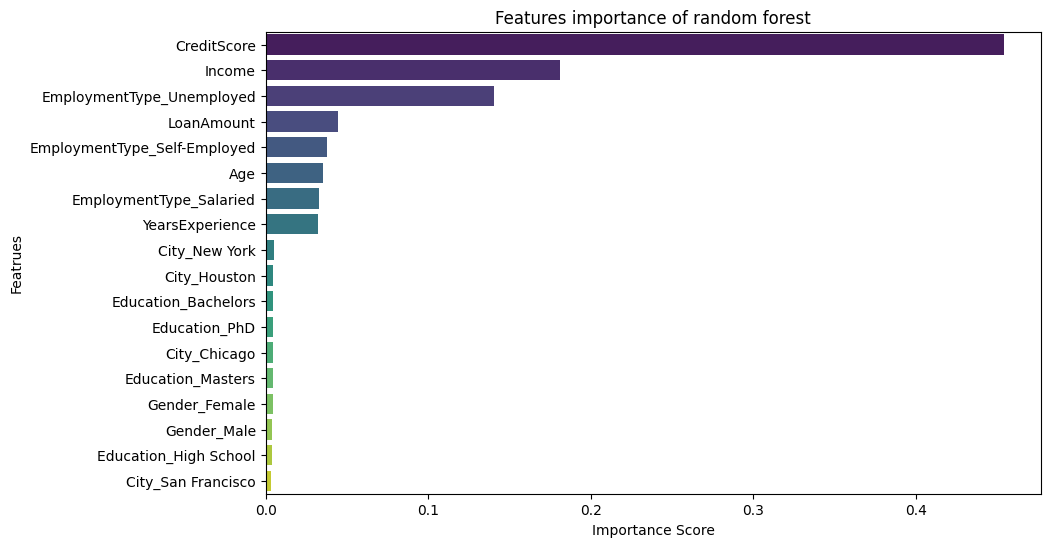

In [105]:
#Calculating Feature Importance 
# we will choose best performaing model
feature_importance = RFC.feature_importances_ #attribute

feat_imp_df = pd.DataFrame({"Feature": x_train.columns, "Importance":feature_importance})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)



# now we will use bar plot to visualize it 
plt.figure(figsize=(10,6))
sns.barplot(x= feat_imp_df['Importance'], y = feat_imp_df['Feature'], palette='viridis')
plt.title("Features importance of random forest")
plt.xlabel("Importance Score")
plt.ylabel("Featrues")

plt.show()